In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages

from scipy.optimize import curve_fit


In [2]:
analyse = AnalysisFunc()
reader = DataRead()
algo = UmapAlgo()
algo_pf = AlgoParFull()
comm_partcptn = CommPercentages()

### Read ST and FPT data from results
- This data from older simulations for which there is no NC data
- Change this analysis data once you fine fit it

In [6]:
params = reader.data_read_pkl(f'results/partial_full_data_200_itr/FN')

In [ ]:
params[1].keys()
# 1 for partial
# 2 for full


dict_keys(['t_t', 'fp_t', 's_t', 'cov'])

In [13]:
part_fpt=params[1]["fp_t"]
part_fpt=[x for x in part_fpt if x>25 and x<1000]
full_fpt=params[2]["fp_t"]  
full_fpt=[x for x in full_fpt if x>25 and x<1000]

full_st=params[2]["s_t"]
full_st=[x for x in full_st if x>25 and x<1000]
part_st=params[1]["s_t"]
part_st=[x for x in part_st if x>25 and x<1000]

In [35]:
min(full_fpt)

25.0

In [ ]:
full_st

#### Explaination behind fitting CCDF
Sort intervals → put waiting times in order.
Compute CCDF → probability of waiting longer than each time.
Take log → so exponential becomes linear.
Fit a line → slope ≈ λ
Plot points + line → check visually if it’s straight.
Return λ → estimated rate of arrivals.
Imagine you’re waiting for ice cream 🍦. Sometimes you wait 2 minutes, sometimes 5 minutes, sometimes 10 minutes. You write down all the waiting times.
Now, if the ice cream man comes randomly (like rolling dice), the times you wait should follow a special "random waiting pattern" called exponential distribution.
How do we check?
We line up all the waiting times from smallest to biggest.
We ask: “What’s the chance I wait longer than this time?” (that’s the CCDF: probability of waiting more than t).
If we draw this chance on a special graph (logarithmic scale), exponential waiting times make a straight line.
If it’s straight, we say: “Yes! My waiting times are exponential.”
The slope of that line tells us how fast the ice cream man usually comes (that’s λ, the rate).

In [8]:
def expo_plot_two_lines(intervals, ax, label, split_index=None):
    # Sort data
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    # Default split: halfway
    if split_index is None:
        split_index = len(intervals) // 2

    # First segment fit
    slope1, intercept1 = np.polyfit(intervals[:split_index], log_ccdf[:split_index], 1)
    lam1 = -slope1

    # Second segment fit
    slope2, intercept2 = np.polyfit(intervals[split_index:], log_ccdf[split_index:], 1)
    lam2 = -slope2

    # Plot scatter
    ax.scatter(intervals, log_ccdf, s=20, alpha=0.7, label=label)

    # Plot first line
    ax.plot(
        intervals[:split_index],
        slope1 * intervals[:split_index] + intercept1,
        'r-',
        label=f'Fit 1 (λ ≈ {lam1:.3f})'
    )

    # Plot second line
    ax.plot(
        intervals[split_index:],
        slope2 * intervals[split_index:] + intercept2,
        'g-',
        label=f'Fit 2 (λ ≈ {lam2:.3f})'
    )

    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF {label} (2 fits)")
    ax.legend()


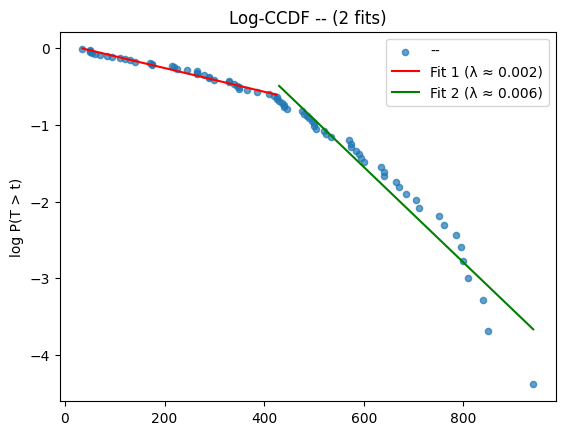

In [17]:
expo_plot_two_lines(full_fpt, plt.gca(), "--")

## Get all data from folder

In [34]:
data_folder = Path('../../data/results/partial_full_data_200_itr/')
files = list(data_folder.glob('*'))
# files = glob.glob(str(data_folder / "*.pkl"))
# params = reader.data_read_pkl(f'results/partial_full_data_200_itr/FN')

In [35]:
files

[WindowsPath('../../data/results/partial_full_data_200_itr/BLA'),
 WindowsPath('../../data/results/partial_full_data_200_itr/ENTI'),
 WindowsPath('../../data/results/partial_full_data_200_itr/FN'),
 WindowsPath('../../data/results/partial_full_data_200_itr/LHA'),
 WindowsPath('../../data/results/partial_full_data_200_itr/LSc'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOB'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOp'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MOs'),
 WindowsPath('../../data/results/partial_full_data_200_itr/MRN'),
 WindowsPath('../../data/results/partial_full_data_200_itr/ORB'),
 WindowsPath('../../data/results/partial_full_data_200_itr/PERI'),
 WindowsPath('../../data/results/partial_full_data_200_itr/PIR'),
 WindowsPath('../../data/results/partial_full_data_200_itr/RE')]

### To plot (saved in results folder)

In [ ]:
fig,axes = plt.subplots(len(files),1, figsize=(8,4*len(files)))
for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
    if file != 'MRN': # change file.name for full st as it's data does not fit

        with open(file, "rb") as f:
            params = pickle.load(f)

        part_fpt=params[1]["fp_t"]
        part_fpt=[x for x in part_fpt if x>25 and x<1000]
        full_fpt=params[2]["fp_t"]  
        full_fpt=[x for x in full_fpt if x>25 and x<1000]

        full_st=params[2]["s_t"]
        full_st=[x for x in full_st if x>25 and x<1000]
        part_st=params[1]["s_t"]
        part_st=[x for x in part_st if x>25 and x<1000]
        expo_plot_two_lines(part_st,ax,f'part_st_{file.name}')
    else:
        continue
  
plt.tight_layout()
plt.savefig('../../data/results/Part ST fit.pdf',format='pdf')



#### Returns line parameters with tolerances
- saved in results folder as csv files
- not done for ST data


In [36]:


def expo_plot_two_lines_params(intervals, label, split_index=None, save_path="../../data/results/fit_part_fpt_params.csv"):
    # Sort data
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    # Default split: halfway
    if split_index is None:
        split_index = len(intervals) // 2

    # First segment fit with covariance
    coeffs1, cov1 = np.polyfit(intervals[:split_index], log_ccdf[:split_index], 1, cov=True)
    slope1, intercept1 = coeffs1
    lam1 = -slope1
    slope1_err, intercept1_err = np.sqrt(np.diag(cov1))

    # Second segment fit with covariance
    coeffs2, cov2 = np.polyfit(intervals[split_index:], log_ccdf[split_index:], 1, cov=True)
    slope2, intercept2 = coeffs2
    lam2 = -slope2
    slope2_err, intercept2_err = np.sqrt(np.diag(cov2))

    # # Plot scatter
    # ax.scatter(intervals, log_ccdf, s=20, alpha=0.7, label=label)

    # # Plot first line
    # ax.plot(
    #     intervals[:split_index],
    #     slope1 * intervals[:split_index] + intercept1,
    #     'r-',
    #     label=f'Fit 1 (λ ≈ {lam1:.3f})'
    # )

    # # Plot second line
    # ax.plot(
    #     intervals[split_index:],
    #     slope2 * intervals[split_index:] + intercept2,
    #     'g-',
    #     label=f'Fit 2 (λ ≈ {lam2:.3f})'
    # )

    # ax.set_ylabel("log P(T > t)")
    # ax.set_title(f"Log-CCDF {label} (2 fits)")
    # ax.legend()

    # Threshold: the first interval where second fit starts
    threshold = intervals[split_index]

    # Collect parameters
    params = {
        "label": label,
        "slope1": slope1, "slope1_err": slope1_err,
        "intercept1": intercept1, "intercept1_err": intercept1_err,
        "lambda1": lam1,
        "slope2": slope2, "slope2_err": slope2_err,
        "intercept2": intercept2, "intercept2_err": intercept2_err,
        "lambda2": lam2,
        "threshold": threshold
    }

    # --- Save to CSV ---
    save_file = Path(save_path)
    df_new = pd.DataFrame([params])

    if save_file.exists():
        df_old = pd.read_csv(save_file)
        df_all = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(save_file, index=False)

    return params


### Change variable names and path accordingly

In [41]:
for file in  files:
    print(f'Processing file: {file}')
    if file != 'MRN': # change file.name for full st as it's data does not fit

        with open(file, "rb") as f:
            params = pickle.load(f)

        part_fpt=params[1]["fp_t"]
        part_fpt=[x for x in part_fpt if x>25 and x<1000]
        full_fpt=params[2]["fp_t"]  
        full_fpt=[x for x in full_fpt if x>25 and x<1000]

        full_st=params[2]["s_t"]
        full_st=[x for x in full_st if x>25 and x<1000]
        part_st=params[1]["s_t"]
        part_st=[x for x in part_st if x>25 and x<1000]
        print(expo_plot_two_lines_params(part_st,f'part_st_{file.name}',save_path="../../data/results/fit_part_st_params.csv"))
    else:
        continue

Processing file: ..\..\data\results\partial_full_data_200_itr\BLA
{'label': 'part_st_BLA', 'slope1': -0.01718390422933848, 'slope1_err': 0.0005727999937687654, 'intercept1': 0.9614820810378161, 'intercept1_err': 0.042880758973463357, 'lambda1': 0.01718390422933848, 'slope2': -0.010969521594553769, 'slope2_err': 0.00027822195940810704, 'intercept2': 0.20188311766727657, 'intercept2_err': 0.05143436886271634, 'lambda2': 0.010969521594553769, 'threshold': 100.0}
Processing file: ..\..\data\results\partial_full_data_200_itr\ENTI
{'label': 'part_st_ENTI', 'slope1': -0.02373968603499844, 'slope1_err': 0.000572868596626835, 'intercept1': 1.3791549686963482, 'intercept1_err': 0.04093355581389495, 'lambda1': 0.02373968603499844, 'slope2': -0.00820323367269393, 'slope2_err': 0.0001960093015464176, 'intercept2': -0.13048225851127526, 'intercept2_err': 0.042198940812149775, 'lambda2': 0.00820323367269393, 'threshold': 90.0}
Processing file: ..\..\data\results\partial_full_data_200_itr\FN
{'label':